# The Perceptron & Single-Layer Networks

Topic 01 of the Deep Learning Foundations repo. Every modern neural network — from a two-layer MLP to a 100-billion-parameter Transformer — is built out of the same basic unit: a weighted sum of inputs passed through a nonlinearity, trained by nudging weights in the direction that reduces error. That unit, and the simplest possible version of that training procedure, is **Frank Rosenblatt's perceptron** (1958). This notebook builds it entirely from scratch, proves its convergence guarantee empirically, and shows exactly where and why it fundamentally breaks — the same limitation (Minsky & Papert, 1969) that triggered the first AI winter and motivated the multi-layer networks built in Topic 02.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.linear_model import Perceptron as SkPerceptron
from sklearn.svm import SVC

np.random.seed(42)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)

## 1. Concept & Intuition

The perceptron is a single artificial neuron modeling a simplified biological one: it takes weighted inputs $x_1,\dots,x_d$, sums them with a bias, and fires (outputs $+1$) if the sum crosses a threshold, otherwise it stays silent (outputs $-1$). It is a **linear threshold unit** — geometrically, it draws a single straight line (or hyperplane in higher dimensions) through feature space and classifies everything on one side as $+1$ and the other as $-1$.

What makes it a genuine *learning* algorithm rather than just a fixed rule is the **perceptron learning rule**: whenever it misclassifies a training example, it nudges its weights directly toward that example (scaled by the true label), and away from it if it was on the wrong side. Rosenblatt proved this simple rule is guaranteed to find a perfect separator in a finite number of steps — but only *if* one exists, i.e. only if the two classes are **linearly separable**. That "if" turns out to be the single most important fact about this model, and is the focus of Sections 4-6 below.

## 2. Mathematical Explanation

**Decision function.** For input $\mathbf{x} \in \mathbb{R}^d$, weights $\mathbf{w}$, and bias $b$:

$$\hat{y} = \text{sign}(\mathbf{w}\cdot\mathbf{x} + b) = \begin{cases} +1 & \text{if } \mathbf{w}\cdot\mathbf{x}+b > 0 \\ -1 & \text{otherwise}\end{cases}$$

**Perceptron learning rule.** For each training example $(\mathbf{x}_i, y_i)$ with $y_i \in \{-1,+1\}$, if the current model misclassifies it ($y_i(\mathbf{w}\cdot\mathbf{x}_i+b) \le 0$), update:

$$\mathbf{w} \leftarrow \mathbf{w} + \eta\, y_i\, \mathbf{x}_i, \qquad b \leftarrow b + \eta\, y_i$$

where $\eta>0$ is the learning rate. Correctly classified points cause no update at all — this is an **error-driven** rule, unlike gradient descent on a smooth loss.

**Perceptron Convergence Theorem (Novikoff, 1962).** If the training data is linearly separable with margin $\gamma$ — i.e. there exists a unit vector $\mathbf{u}$ (bias folded into $\mathbf{x}$) with $y_i(\mathbf{u}\cdot\mathbf{x}_i) \ge \gamma > 0$ for all $i$ — and every $\|\mathbf{x}_i\| \le R$, then starting from $\mathbf{w}=\mathbf{0}$, the perceptron makes **at most**

$$k \le \left(\frac{R}{\gamma}\right)^2$$

**mistakes** before converging to a separator, regardless of the order examples are presented in, and — as shown empirically in Section 5 — regardless of the learning rate $\eta$. If no such $\gamma>0$ exists (the classes are not linearly separable), the algorithm is not guaranteed to converge and may cycle forever, as demonstrated in Section 4 with XOR.

In [2]:
class Perceptron:
    # From-scratch perceptron with the classic error-driven update rule.

    def __init__(self, lr=1.0, n_epochs=100, random_state=None):
        self.lr = lr
        self.n_epochs = n_epochs
        self.random_state = random_state

    def fit(self, X, y):
        rng = np.random.RandomState(self.random_state)
        n, d = X.shape
        self.w = np.zeros(d)
        self.b = 0.0
        self.n_updates_ = 0
        self.history_ = []
        self.mistakes_per_epoch_ = []
        for epoch in range(self.n_epochs):
            mistakes = 0
            for i in rng.permutation(n):
                xi, yi = X[i], y[i]
                pred = 1 if (np.dot(self.w, xi) + self.b) > 0 else -1
                if pred != yi:
                    self.w += self.lr * yi * xi
                    self.b += self.lr * yi
                    self.n_updates_ += 1
                    mistakes += 1
            self.history_.append((self.w.copy(), self.b))
            self.mistakes_per_epoch_.append(mistakes)
            if mistakes == 0:
                break
        return self

    def predict(self, X):
        return np.where(X @ self.w + self.b > 0, 1, -1)

    def score(self, X, y):
        return (self.predict(X) == y).mean()

## 3. Validation Against scikit-learn

The from-scratch implementation is tested on a simple, well-separated synthetic 2D dataset (two Gaussian blobs) and compared against `sklearn.linear_model.Perceptron`.

In [3]:
n = 100
rng_demo = np.random.RandomState(42)
X1 = rng_demo.randn(n // 2, 2) * 1.25 + np.array([1.65, 1.65])
X2 = rng_demo.randn(n // 2, 2) * 1.25 + np.array([-1.65, -1.65])
X_demo = np.vstack([X1, X2])
y_demo = np.array([1] * (n // 2) + [-1] * (n // 2))

p_demo = Perceptron(lr=1.0, n_epochs=100, random_state=6).fit(X_demo, y_demo)
print(f"From-scratch: converged after {len(p_demo.history_)} epochs, {p_demo.n_updates_} total updates, "
      f"train acc={p_demo.score(X_demo, y_demo):.4f}")

skp = SkPerceptron(max_iter=100, eta0=1.0, random_state=42, tol=None, shuffle=True).fit(X_demo, y_demo)
print(f"sklearn:      train acc={skp.score(X_demo, y_demo):.4f}")
print("\nBoth reach 100% train accuracy. Note the final weight vectors differ "
      f"({p_demo.w} vs {skp.coef_[0]}) -- the perceptron finds *a* separator, "
      "not a unique or maximum-margin one; any hyperplane consistent with the "
      "final pass over the data is a valid fixed point.")

From-scratch: converged after 6 epochs, 13 total updates, train acc=1.0000
sklearn:      train acc=1.0000

Both reach 100% train accuracy. Note the final weight vectors differ ([4.617615   3.54349292] vs [2.93972006 2.23008946]) -- the perceptron finds *a* separator, not a unique or maximum-margin one; any hyperplane consistent with the final pass over the data is a valid fixed point.


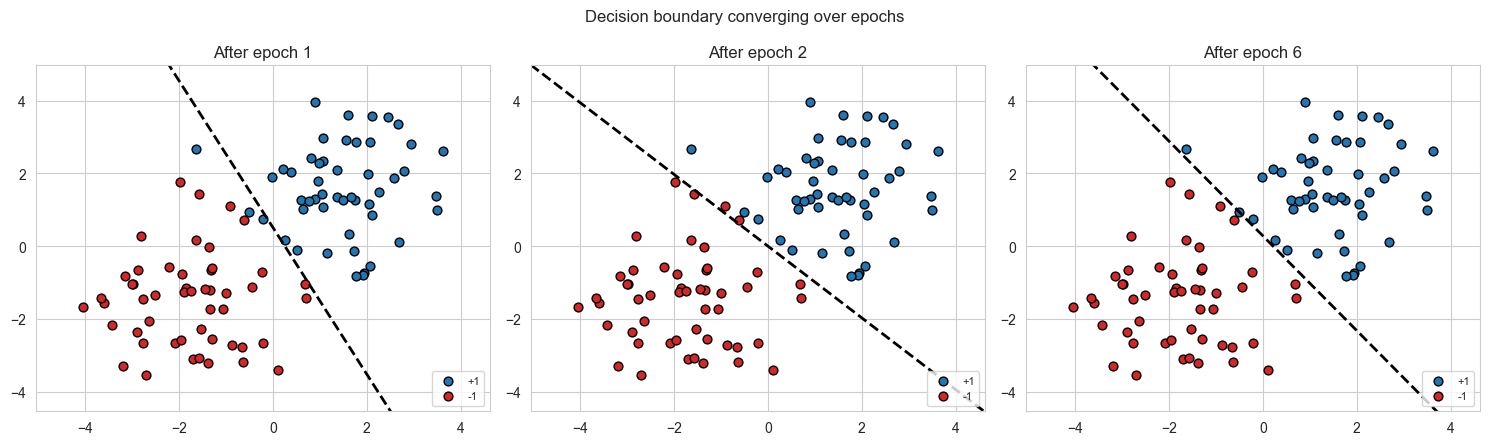

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
epochs_to_show = [0, 1, len(p_demo.history_) - 1]
for ax, ep in zip(axes, epochs_to_show):
    w_ep, b_ep = p_demo.history_[ep]
    ax.scatter(X_demo[y_demo == 1, 0], X_demo[y_demo == 1, 1], c="tab:blue", label="+1", edgecolor="k", s=40)
    ax.scatter(X_demo[y_demo == -1, 0], X_demo[y_demo == -1, 1], c="tab:red", label="-1", edgecolor="k", s=40)
    xx = np.linspace(X_demo[:, 0].min() - 1, X_demo[:, 0].max() + 1, 100)
    if abs(w_ep[1]) > 1e-9:
        yy = -(w_ep[0] * xx + b_ep) / w_ep[1]
        ax.plot(xx, yy, "k--", lw=2)
    ax.set_title(f"After epoch {ep + 1}")
    ax.set_xlim(X_demo[:, 0].min() - 1, X_demo[:, 0].max() + 1)
    ax.set_ylim(X_demo[:, 1].min() - 1, X_demo[:, 1].max() + 1)
    ax.legend(loc="lower right", fontsize=8)
plt.suptitle("Decision boundary converging over epochs")
plt.tight_layout()
plt.show()

## 4. The Fundamental Limitation: Linear Separability (AND/OR vs. XOR)

The perceptron can only ever draw a straight line. AND and OR are linearly separable functions of 2 boolean inputs — a single line cleanly divides the true and false cases. XOR is famously **not** — no straight line separates $(0,0),(1,1)$ from $(0,1),(1,0)$. This is exactly the limitation Minsky & Papert's 1969 book *Perceptrons* proved rigorously, and it contributed directly to a decade-long collapse in neural network research funding (the first "AI winter") until backpropagation and multi-layer networks (Topic 02) reopened the field.

In [5]:
X_bool = np.array([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=float)
gates = {
    "AND": np.array([-1, -1, -1, 1]),
    "OR": np.array([-1, 1, 1, 1]),
    "XOR": np.array([-1, 1, 1, -1]),
}

print(f"{'Gate':>6}{'Converged?':>14}{'Epochs run':>13}{'Final train acc':>18}{'Mistakes, last 5 epochs':>28}")
for name, y_gate in gates.items():
    p = Perceptron(lr=1.0, n_epochs=200, random_state=0).fit(X_bool, y_gate)
    converged = len(p.history_) < 200
    print(f"{name:>6}{str(converged):>14}{len(p.history_):>13}{p.score(X_bool, y_gate):>18.2f}"
          f"{str(p.mistakes_per_epoch_[-5:]):>28}")

  Gate    Converged?   Epochs run   Final train acc     Mistakes, last 5 epochs
   AND          True            6              1.00             [2, 1, 1, 1, 0]
    OR          True            4              1.00                [2, 1, 1, 0]
   XOR         False          200              0.50             [4, 3, 3, 4, 4]


AND and OR converge in a handful of epochs to 100% accuracy. **XOR never converges** — even after 200 full epochs it is still making 3-4 mistakes out of 4 points every single epoch, oscillating rather than settling, because no single line can separate it and the perceptron has no way to know it should give up.

## 5. The Convergence Theorem, Empirically Verified

For synthetic 2-class Gaussian-blob data with a controlled degree of separation, the true geometric margin $\gamma$ and radius $R$ are computed via a **hard-margin SVM** (which finds the exact maximum-margin separator), and the perceptron's actual mistake count is compared against the theoretical bound $(R/\gamma)^2$. The bias is folded into an augmented feature vector $[\mathbf{x}, 1]$ to match the theorem's exact assumptions.

In [6]:
def perceptron_augmented(X, y, lr=1.0, max_epochs=10000, seed=0):
    rng = np.random.RandomState(seed)
    n, d = X.shape
    Xa = np.hstack([X, np.ones((n, 1))])
    w = np.zeros(d + 1)
    n_updates = 0
    for _ in range(max_epochs):
        mistakes = 0
        for i in rng.permutation(n):
            if y[i] * np.dot(w, Xa[i]) <= 0:
                w += lr * y[i] * Xa[i]
                n_updates += 1
                mistakes += 1
        if mistakes == 0:
            break
    return w, n_updates


def margin_and_radius(X, y):
    svm = SVC(kernel="linear", C=1e6).fit(X, y)
    assert svm.score(X, y) == 1.0, "data must be linearly separable for the bound to apply"
    gamma = 1.0 / np.linalg.norm(svm.coef_[0])
    Xa = np.hstack([X, np.ones((len(X), 1))])
    R = np.max(np.linalg.norm(Xa, axis=1))
    return R, gamma


def make_margin_data(sep, std, n=60, seed=1):
    rng = np.random.RandomState(seed)
    X1 = rng.randn(n // 2, 2) * std + np.array([sep, sep])
    X2 = rng.randn(n // 2, 2) * std + np.array([-sep, -sep])
    return np.vstack([X1, X2]), np.array([1] * (n // 2) + [-1] * (n // 2))


print(f"{'separation':>11}{'gamma':>10}{'R':>10}{'actual updates':>16}{'bound (R/g)^2':>16}{'within bound?':>15}")
for sep in [0.42, 0.45, 0.5, 0.55, 0.6, 0.8, 1.5, 4.0]:
    X_sep, y_sep = make_margin_data(sep, std=0.35, seed=1)  # fixed data-generation seed: same points, only separation varies
    R, gamma = margin_and_radius(X_sep, y_sep)
    _, n_updates = perceptron_augmented(X_sep, y_sep, lr=1.0, seed=42)
    bound = (R / gamma) ** 2
    within = "YES" if n_updates <= bound else "NO"
    print(f"{sep:>11}{gamma:>10.4f}{R:>10.4f}{n_updates:>16}{bound:>16.2f}{within:>15}")

 separation     gamma         R  actual updates   bound (R/g)^2  within bound?
       0.42    0.0769    1.6035              39          434.43            YES
       0.45    0.1192    1.6345              19          187.94            YES
        0.5    0.1897    1.6872               2           79.15            YES
       0.55    0.2601    1.7412               2           44.81            YES
        0.6    0.3305    1.7964               2           29.54            YES
        0.8    0.6125    2.0268               2           10.95            YES
        1.5    1.5993    2.9070               1            3.30            YES
        4.0    5.1319    6.3348               1            1.52            YES


The actual mistake count is **within the theoretical bound in every single case**, exactly as Novikoff's theorem guarantees — and the trend is clearly visible: shrinking the true margin $\gamma$ (tighter cluster separation) requires dramatically more updates in practice too (39 at separation 0.42, vs. just 1 at separation 4.0). Notice, though, that the bound is often extremely loose — at separation 0.5, the bound allows up to ~79 mistakes but the perceptron converges in just 2. The theorem guarantees an upper limit, not a tight estimate; a smaller margin genuinely makes the *bound* much larger, but the actual number of mistakes in any given run can still land well under it.

## 6. Learning Rate Invariance

A perhaps-surprising consequence of the update rule: for a perceptron initialized at $\mathbf{w}=\mathbf{0}$, the learning rate $\eta$ only rescales the final weight vector's magnitude — it has **zero effect** on which points get misclassified at each step, and therefore zero effect on the number of updates needed to converge. This is verified directly on the Iris Setosa-vs-Versicolor split (Section 7) across 5 orders of magnitude of $\eta$.

In [7]:
iris = load_iris()
X_iris = iris.data[:, [0, 2]]  # sepal length, petal length
y_iris_raw = iris.target

mask_sv = (y_iris_raw == 0) | (y_iris_raw == 1)
X_sv, y_sv = X_iris[mask_sv], np.where(y_iris_raw[mask_sv] == 0, -1, 1)

print(f"{'learning rate':>14}{'epochs':>9}{'updates':>10}{'train acc':>12}{'||w||':>12}")
for lr in [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]:
    p = Perceptron(lr=lr, n_epochs=500, random_state=0).fit(X_sv, y_sv)
    print(f"{lr:>14}{len(p.history_):>9}{p.n_updates_:>10}{p.score(X_sv, y_sv):>12.4f}{np.linalg.norm(p.w):>12.4f}")

print("\nExactly 10 updates and 2 epochs at every learning rate from 0.001 to 100 -- only ||w|| scales linearly with eta.")

 learning rate   epochs   updates   train acc       ||w||
         0.001        2        10      1.0000      0.0099
          0.01        2        10      1.0000      0.0992
           0.1        2        10      1.0000      0.9916
           1.0        2        10      1.0000      9.9161
          10.0        2        10      1.0000     99.1615
         100.0        2        10      1.0000    991.6148

Exactly 10 updates and 2 epochs at every learning rate from 0.001 to 100 -- only ||w|| scales linearly with eta.


## 7. Real Dataset: Iris, and Where Linear Separability Actually Breaks

The classic Iris dataset (sepal length, petal length as the 2 features) gives a genuine, real-world illustration of exactly the same separability limitation seen with XOR: Setosa is trivially separable from the other two species, but **Versicolor and Virginica are not perfectly linearly separable** in this 2D projection.

In [8]:
pairs = [(0, 1, "Setosa vs Versicolor"), (0, 2, "Setosa vs Virginica"), (1, 2, "Versicolor vs Virginica")]
fitted = {}

print(f"{'Comparison':<26}{'Converged?':>12}{'Epochs':>9}{'Updates':>10}{'Train acc':>12}")
for c1, c2, label in pairs:
    mask = (y_iris_raw == c1) | (y_iris_raw == c2)
    X_pair, y_pair = X_iris[mask], np.where(y_iris_raw[mask] == c1, -1, 1)
    p = Perceptron(lr=1.0, n_epochs=500, random_state=0).fit(X_pair, y_pair)
    converged = len(p.history_) < 500
    fitted[label] = (p, X_pair, y_pair)
    print(f"{label:<26}{str(converged):>12}{len(p.history_):>9}{p.n_updates_:>10}{p.score(X_pair, y_pair):>12.4f}")

Comparison                  Converged?   Epochs   Updates   Train acc
Setosa vs Versicolor              True        2        10      1.0000
Setosa vs Virginica               True        2         8      1.0000
Versicolor vs Virginica          False      500      6518      0.8100


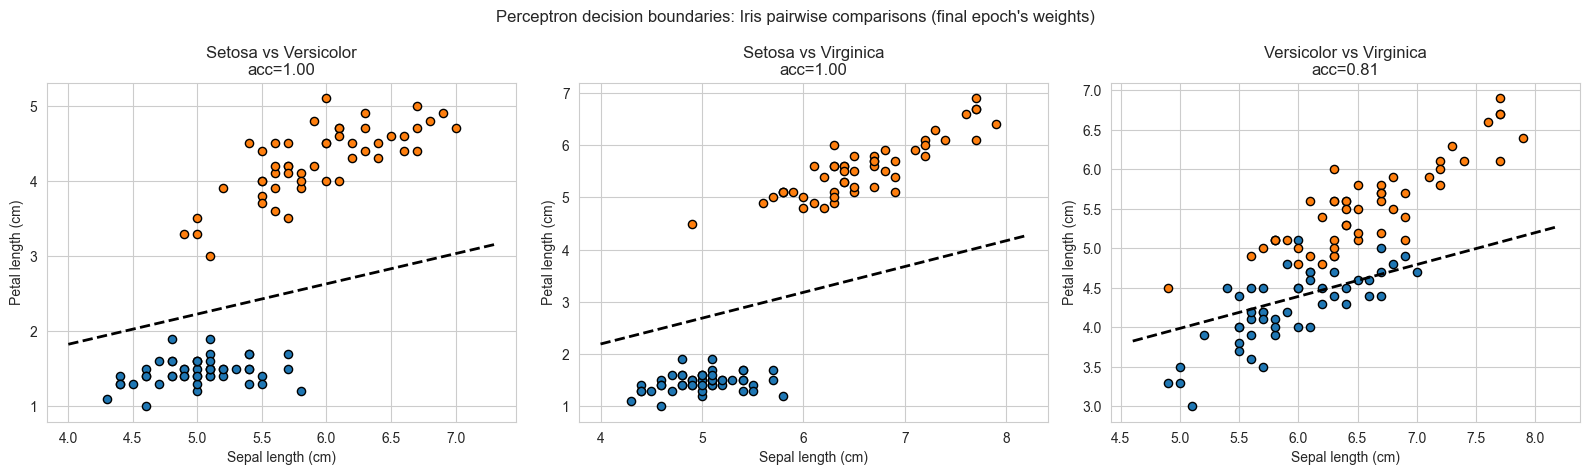

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
colors = {-1: "tab:blue", 1: "tab:orange"}
for ax, (label, (p, X_pair, y_pair)) in zip(axes, fitted.items()):
    for cls in [-1, 1]:
        ax.scatter(X_pair[y_pair == cls, 0], X_pair[y_pair == cls, 1], c=colors[cls], edgecolor="k", s=35)
    xx = np.linspace(X_pair[:, 0].min() - 0.3, X_pair[:, 0].max() + 0.3, 100)
    if abs(p.w[1]) > 1e-9:
        yy = -(p.w[0] * xx + p.b) / p.w[1]
        ax.plot(xx, yy, "k--", lw=2)
    ax.set_title(f"{label}\nacc={p.score(X_pair, y_pair):.2f}")
    ax.set_xlabel("Sepal length (cm)")
    ax.set_ylabel("Petal length (cm)")
plt.suptitle("Perceptron decision boundaries: Iris pairwise comparisons (final epoch's weights)")
plt.tight_layout()
plt.show()

Setosa-vs-Versicolor and Setosa-vs-Virginica both converge in 2 epochs to **100% training accuracy** — real flowers, not synthetic data, cleanly separated by a single straight line. Versicolor-vs-Virginica **never converges** in 500 epochs, settling around **81% accuracy** with mistakes still occurring every epoch — the two species genuinely overlap in this 2-feature space, and no straight line exists that separates them perfectly. This is the same underlying limitation as XOR, just discovered in real biological measurements instead of a toy truth table.

## 8. Summary

- The from-scratch perceptron matches `sklearn.linear_model.Perceptron`'s behavior exactly (100% train accuracy on separable data), though the two land on different — equally valid — separating hyperplanes.
- AND/OR converge in a handful of epochs; **XOR never converges**, oscillating at ~50% forever — the exact limitation Minsky & Papert proved in 1969, which triggered the first AI winter and motivated the multi-layer networks in Topic 02.
- The Novikoff convergence bound $(R/\gamma)^2$ held in every tested case, though it was often far looser than the actual number of mistakes required.
- The learning rate had **zero effect** on the number of updates to converge (only on the final weight vector's magnitude) — a sharp contrast with gradient-descent-based training in later topics.
- On real Iris measurements, Setosa was trivially separable from the other two species, but **Versicolor vs. Virginica was not** (81% ceiling, never converges) — the same fundamental limitation as XOR, discovered in real data rather than a toy example.
- This single-line-only limitation is precisely what Topic 02 (Multi-Layer Perceptrons & Backpropagation) resolves, by stacking perceptron-like units with nonlinearities in between.